In [1]:
#essentially all this does is find the closest orthonormal matrix
# A is the original matrix and 
def zeropower_via_newtonschulz5(G, steps=5):
    assert G.ndim == 2
    a, b, c = 3.4445, -4.7750, 2.0315
    X = G.bfloat16()
    X = X / (X.norm() + 1e-7)
    transpose = G.size(-2) > G.size(-1)
    if transpose:
        X = X.mT
    for _ in range(steps):
        A = X @ X.mT
        B = b * A + c * (A @ A)
        X = a * X + B @ X
    if transpose:
        X = X.mT
    return X

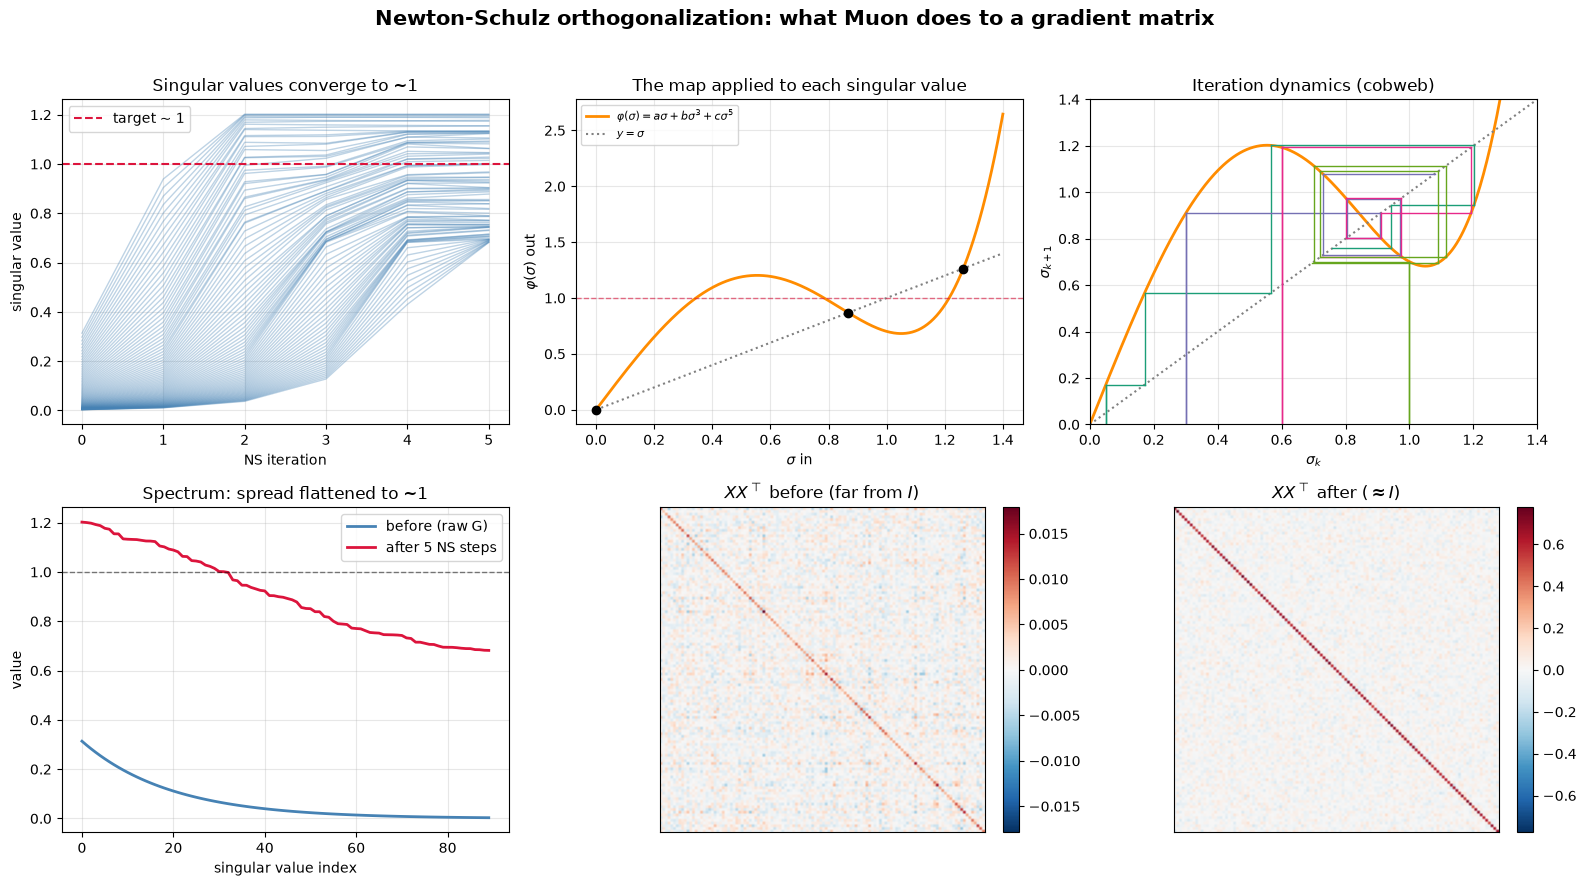

singular values before: min=0.003 max=0.314
singular values after : min=0.682 max=1.202  (want all ~ 1)


In [2]:
# ---- Newton-Schulz visualizer ----
# NS acts on each singular value via phi(s) = a*s + b*s^3 + c*s^5, leaving the
# singular vectors alone and pulling every singular value into a band around 1.
%matplotlib inline
import torch
import numpy as np
import matplotlib.pyplot as plt

A, B, C = 3.4445, -4.7750, 2.0315


def ns_trace(G, steps=5, dtype=torch.float64):
    X = G.to(dtype)
    X = X / (X.norm() + 1e-7)
    transpose = X.size(-2) > X.size(-1)
    if transpose:
        X = X.mT
    frames = [X.clone()]
    for _ in range(steps):
        AA = X @ X.mT
        X = A * X + (B * AA + C * (AA @ AA)) @ X
        frames.append(X.clone())
    if transpose:
        frames = [f.mT for f in frames]
    return frames


def phi(s):
    return A * s + B * s**3 + C * s**5


def fixed_points():
    fps = [0.0]
    for u in np.roots([C, B, A - 1.0]):        # phi(s)=s  ->  C*u^2 + B*u + (A-1)=0, u=s^2
        if abs(u.imag) < 1e-9 and u.real > 0:
            fps.append(float(np.sqrt(u.real)))
    return fps


def cobweb(ax, x0, n, color):
    x = x0
    ax.plot([x, x], [0, phi(x)], color=color, lw=1)
    for _ in range(n):
        y = phi(x)
        ax.plot([x, x], [0 if x == x0 else x, y], color=color, lw=1)
        ax.plot([x, y], [y, y], color=color, lw=1)
        x = y


def heatmap(ax, M, title):
    v = np.abs(M).max()
    im = ax.imshow(M, cmap="RdBu_r", vmin=-v, vmax=v)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


def make_figure(rows=120, cols=90, steps=5, seed=0):
    g = torch.Generator().manual_seed(seed)
    U, _ = torch.linalg.qr(torch.randn(rows, rows, generator=g, dtype=torch.float64))
    V, _ = torch.linalg.qr(torch.randn(cols, cols, generator=g, dtype=torch.float64))
    k = min(rows, cols)
    G = U[:, :k] @ torch.diag(torch.logspace(0, -2, k, dtype=torch.float64)) @ V[:, :k].T

    frames = ns_trace(G, steps=steps)
    sv = np.stack([torch.linalg.svdvals(f).numpy() for f in frames])

    fig, ax = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle("Newton-Schulz orthogonalization: what Muon does to a gradient matrix",
                 fontsize=15, fontweight="bold")

    xs = np.arange(steps + 1)
    for j in range(sv.shape[1]):
        ax[0, 0].plot(xs, sv[:, j], color="steelblue", alpha=0.35, lw=1)
    ax[0, 0].axhline(1.0, color="crimson", ls="--", lw=1.5, label="target ~ 1")
    ax[0, 0].set_title("Singular values converge to ~1")
    ax[0, 0].set_xlabel("NS iteration"); ax[0, 0].set_ylabel("singular value")
    ax[0, 0].legend(); ax[0, 0].grid(alpha=0.3)

    s = np.linspace(0, 1.4, 400)
    ax[0, 1].plot(s, phi(s), color="darkorange", lw=2, label=r"$\varphi(\sigma)=a\sigma+b\sigma^3+c\sigma^5$")
    ax[0, 1].plot(s, s, color="gray", ls=":", lw=1.5, label=r"$y=\sigma$")
    ax[0, 1].axhline(1.0, color="crimson", ls="--", lw=1, alpha=0.6)
    for fp in fixed_points():
        ax[0, 1].plot(fp, fp, "o", color="black", ms=6)
    ax[0, 1].set_title("The map applied to each singular value")
    ax[0, 1].set_xlabel(r"$\sigma$ in"); ax[0, 1].set_ylabel(r"$\varphi(\sigma)$ out")
    ax[0, 1].legend(fontsize=8); ax[0, 1].grid(alpha=0.3)

    ax[0, 2].plot(s, phi(s), color="darkorange", lw=2)
    ax[0, 2].plot(s, s, color="gray", ls=":", lw=1.5)
    for x0, col in zip([0.05, 0.3, 0.6, 1.0], ["#1b9e77", "#7570b3", "#e7298a", "#66a61e"]):
        cobweb(ax[0, 2], x0, steps, col)
    ax[0, 2].set_title("Iteration dynamics (cobweb)")
    ax[0, 2].set_xlabel(r"$\sigma_k$"); ax[0, 2].set_ylabel(r"$\sigma_{k+1}$")
    ax[0, 2].set_xlim(0, 1.4); ax[0, 2].set_ylim(0, 1.4); ax[0, 2].grid(alpha=0.3)

    idx = np.arange(sv.shape[1])
    ax[1, 0].plot(idx, sv[0], color="steelblue", lw=2, label="before (raw G)")
    ax[1, 0].plot(idx, sv[-1], color="crimson", lw=2, label=f"after {steps} NS steps")
    ax[1, 0].axhline(1.0, color="black", ls="--", lw=1, alpha=0.5)
    ax[1, 0].set_title("Spectrum: spread flattened to ~1")
    ax[1, 0].set_xlabel("singular value index"); ax[1, 0].set_ylabel("value")
    ax[1, 0].legend(); ax[1, 0].grid(alpha=0.3)

    heatmap(ax[1, 1], (frames[0] @ frames[0].mT).numpy(), r"$X X^\top$ before (far from $I$)")
    heatmap(ax[1, 2], (frames[-1] @ frames[-1].mT).numpy(), r"$X X^\top$ after ($\approx I$)")

    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    print(f"singular values before: min={sv[0].min():.3f} max={sv[0].max():.3f}")
    print(f"singular values after : min={sv[-1].min():.3f} max={sv[-1].max():.3f}  (want all ~ 1)")


make_figure()


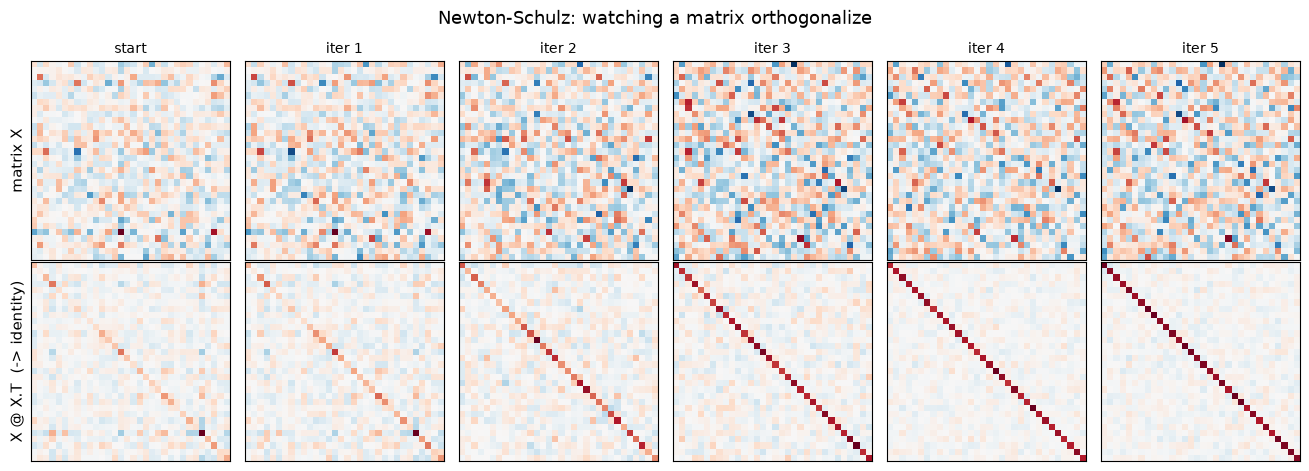

singular values  before: min=0.005 max=0.507
singular values  after : min=0.682 max=1.147   (want all near 1)


In [3]:
# ---- Newton-Schulz matrix filmstrip ----
# Watch the matrix orthogonalize step by step, as colored heatmaps.
# ns_trace keeps EVERY iterate (float for clean colors; training uses bf16).
def ns_trace(G, steps=5):
    a, b, c = 3.4445, -4.7750, 2.0315
    X = G.float()
    X = X / (X.norm() + 1e-7)
    transpose = X.size(-2) > X.size(-1)
    if transpose:
        X = X.mT
    frames = [X.clone()]
    for _ in range(steps):
        A = X @ X.mT
        B = b * A + c * (A @ A)
        X = a * X + B @ X
        frames.append(X.clone())
    if transpose:
        frames = [f.mT for f in frames]
    return frames


def show_matrix_evolution(n=32, steps=5, seed=0):
    g = torch.Generator().manual_seed(seed)
    U, _ = torch.linalg.qr(torch.randn(n, n, generator=g))
    V, _ = torch.linalg.qr(torch.randn(n, n, generator=g))
    G = U @ torch.diag(torch.logspace(0, -2, n)) @ V.T   # spread-out spectrum so colors shift

    frames = ns_trace(G, steps=steps)

    # Top row: the matrix X at each iteration.
    # Bottom row: X @ X.T, marching toward the identity as X becomes orthonormal.
    fig, axes = plt.subplots(2, steps + 1, figsize=(2.2 * (steps + 1), 4.8))
    for i, X in enumerate(frames):
        M = X.numpy(); v = np.abs(M).max()
        axes[0, i].imshow(M, cmap="RdBu_r", vmin=-v, vmax=v)
        axes[0, i].set_title("start" if i == 0 else f"iter {i}", fontsize=10)
        axes[0, i].set_xticks([]); axes[0, i].set_yticks([])
        gram = (X @ X.mT).numpy(); gv = np.abs(gram).max()
        axes[1, i].imshow(gram, cmap="RdBu_r", vmin=-gv, vmax=gv)
        axes[1, i].set_xticks([]); axes[1, i].set_yticks([])

    axes[0, 0].set_ylabel("matrix X", fontsize=11)
    axes[1, 0].set_ylabel("X @ X.T  (-> identity)", fontsize=11)
    fig.suptitle("Newton-Schulz: watching a matrix orthogonalize", fontsize=13)
    fig.tight_layout()
    plt.show()

    sv0 = torch.linalg.svdvals(frames[0]).numpy()
    sv1 = torch.linalg.svdvals(frames[-1]).numpy()
    print(f"singular values  before: min={sv0.min():.3f} max={sv0.max():.3f}")
    print(f"singular values  after : min={sv1.min():.3f} max={sv1.max():.3f}   (want all near 1)")


show_matrix_evolution(n=32, steps=5)


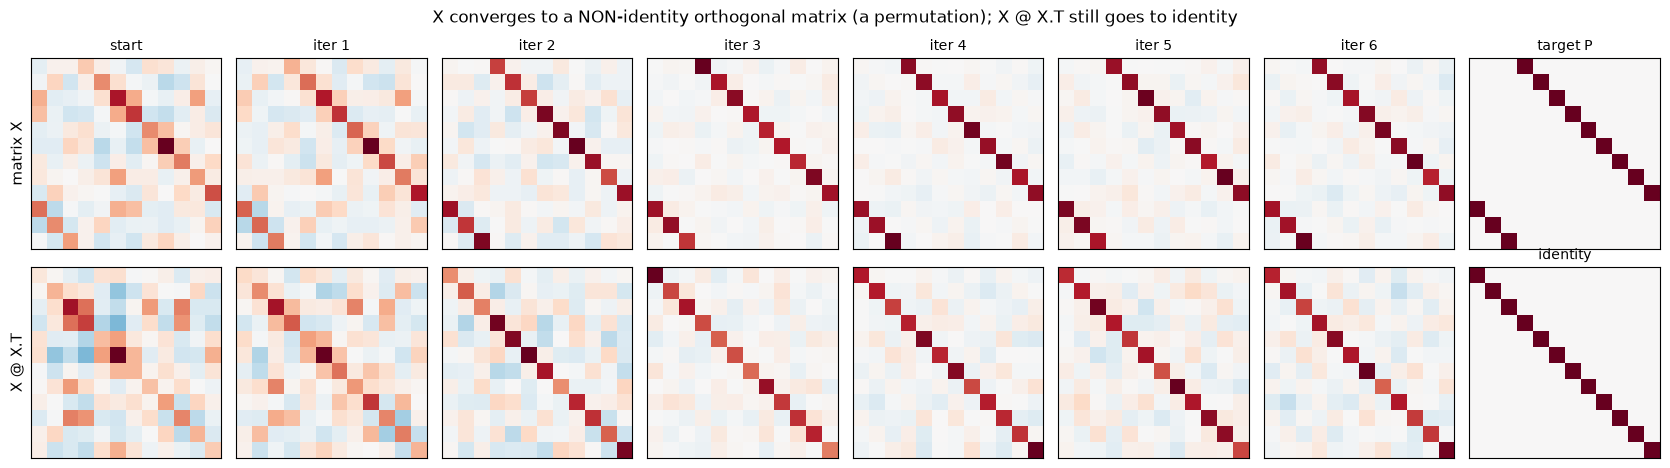

final X matches the shifted-diagonal permutation (not the identity): True


In [4]:
# ---- Filmstrip converging to a NON-identity orthogonal matrix ----
# The answer here is a permutation (a shifted diagonal stripe), clearly not the identity.
# G = P @ M:  P is the permutation (orthogonal part), M is an SPD "stretch".
# NS strips M away and recovers P, while X @ X.T still marches to the identity.
def show_evolution_to_target(n=12, shift=3, steps=6, seed=0):
    g = torch.Generator().manual_seed(seed)
    P = torch.zeros(n, n)
    for i in range(n):
        P[i, (i + shift) % n] = 1.0
    Q, _ = torch.linalg.qr(torch.randn(n, n, generator=g))
    M = Q @ torch.diag(torch.logspace(0, -1.5, n)) @ Q.T
    G = P @ M

    frames = ns_trace(G, steps=steps)

    fig, axes = plt.subplots(2, steps + 2, figsize=(2.1 * (steps + 2), 4.8))
    for i, X in enumerate(frames):
        Mx = X.numpy(); v = np.abs(Mx).max()
        axes[0, i].imshow(Mx, cmap="RdBu_r", vmin=-v, vmax=v)
        axes[0, i].set_title("start" if i == 0 else f"iter {i}", fontsize=10)
        axes[0, i].set_xticks([]); axes[0, i].set_yticks([])
        gram = (X @ X.mT).numpy(); gv = np.abs(gram).max()
        axes[1, i].imshow(gram, cmap="RdBu_r", vmin=-gv, vmax=gv)
        axes[1, i].set_xticks([]); axes[1, i].set_yticks([])

    axes[0, -1].imshow(P.numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
    axes[0, -1].set_title("target P", fontsize=10)
    axes[0, -1].set_xticks([]); axes[0, -1].set_yticks([])
    axes[1, -1].imshow(np.eye(n), cmap="RdBu_r", vmin=-1, vmax=1)
    axes[1, -1].set_title("identity", fontsize=10)
    axes[1, -1].set_xticks([]); axes[1, -1].set_yticks([])

    axes[0, 0].set_ylabel("matrix X", fontsize=11)
    axes[1, 0].set_ylabel("X @ X.T", fontsize=11)
    fig.suptitle("X converges to a NON-identity orthogonal matrix (a permutation); X @ X.T still goes to identity",
                 fontsize=12)
    fig.tight_layout()
    plt.show()

    matches = all(int(frames[-1][i].argmax()) == int((P[i] > 0.5).nonzero()[0]) for i in range(n))
    print(f"final X matches the shifted-diagonal permutation (not the identity): {matches}")


show_evolution_to_target(n=12, shift=3, steps=6)
